# 03 · EDA – Análisis de distribuciones y análisis univariado
**Responsable:** María Camila
**Objetivo:** estudiar cada variable por separado: estadísticos descriptivos, forma de la distribución (sesgo, curtosis, normalidad), transformaciones necesarias y frecuencias de las variables categóricas.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.append(str(Path.cwd().parent))   # para poder importar src/
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils import (configurar_graficos, cargar_datos, guardar_figura,
                       VARIABLES_NUMERICAS, VARIABLES_CATEGORICAS, OBJETIVO,
                       RUTA_PROCESADOS)
configurar_graficos()
from scipy import stats
df = pd.read_csv(RUTA_PROCESADOS / "bank_limpio.csv")
print(df.shape)
df.head()

(41176, 22)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y,contactado_antes
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,...,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0,0
1,53,technician,married,university.degree,no,no,no,cellular,nov,fri,...,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0,0
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,...,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1,1
3,39,services,married,high.school,no,no,no,cellular,apr,fri,...,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0,0
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,fri,...,3,1,success,-2.9,92.201,-31.4,0.869,5076.2,1,1


## 1. Variable objetivo

   clientes      %
y                 
0     36537  88.73
1      4639  11.27


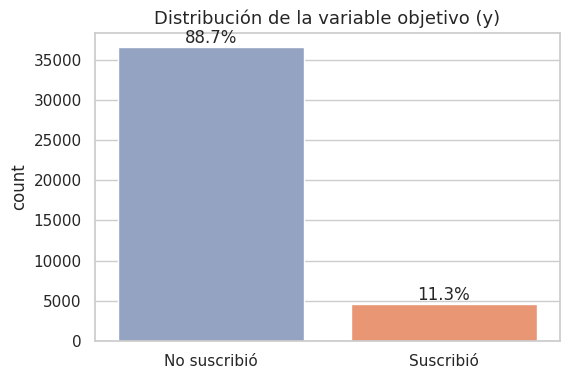

In [2]:
conteo = df[OBJETIVO].value_counts()
pct = df[OBJETIVO].value_counts(normalize=True) * 100
print(pd.DataFrame({"clientes": conteo, "%": pct.round(2)}))

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x=df[OBJETIVO].map({0: "No suscribió", 1: "Suscribió"}), ax=ax, palette=["#8da0cb", "#fc8d62"])
for p in ax.patches:
    ax.annotate(f"{p.get_height()/len(df)*100:.1f}%", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
ax.set_xlabel(""); ax.set_title("Distribución de la variable objetivo (y)")
guardar_figura("03_objetivo")
plt.show()

El dataset está **desbalanceado**: solo ~11 % de los clientes suscribió el depósito. Esto se debe tener en cuenta en un futuro modelado (métricas como *recall*, F1 o AUC en lugar de *accuracy*).

## 2. Estadísticos descriptivos de las variables numéricas

In [3]:
num = [c for c in VARIABLES_NUMERICAS if c != "pdays"]
desc = df[num].describe().T
desc["asimetria"] = df[num].skew()
desc["curtosis"] = df[num].kurt()
desc["coef_variacion_%"] = (desc["std"] / desc["mean"].abs() * 100)
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,asimetria,curtosis,coef_variacion_%
age,41176.0,40.02,10.42,17.00,32.00,38.00,47.00,98.00,0.78,0.79,26.04
duration,41176.0,258.32,259.31,0.00,102.00,180.00,319.00,4918.00,3.26,20.24,100.38
campaign,41176.0,2.50,2.30,1.00,1.00,2.00,3.00,14.00,2.70,8.71,92.05
previous,41176.0,0.17,0.49,0.00,0.00,0.00,0.00,7.00,3.83,20.10,286.08
emp_var_rate,41176.0,0.08,1.57,-3.40,-1.80,1.10,1.40,1.40,-0.72,-1.06,1917.55
cons_price_idx,41176.0,93.58,0.58,92.20,93.08,93.75,93.99,94.77,-0.23,-0.83,0.62
cons_conf_idx,41176.0,-40.50,4.63,-50.80,-42.70,-41.80,-36.40,-26.90,0.30,-0.36,11.43
euribor3m,41176.0,3.62,1.73,0.63,1.34,4.86,4.96,5.04,-0.71,-1.41,47.90
nr_employed,41176.0,5167.03,72.25,4963.60,5099.10,5191.00,5228.10,5228.10,-1.04,-0.00,1.40


## 3. Forma de las distribuciones: histogramas + curvas de densidad

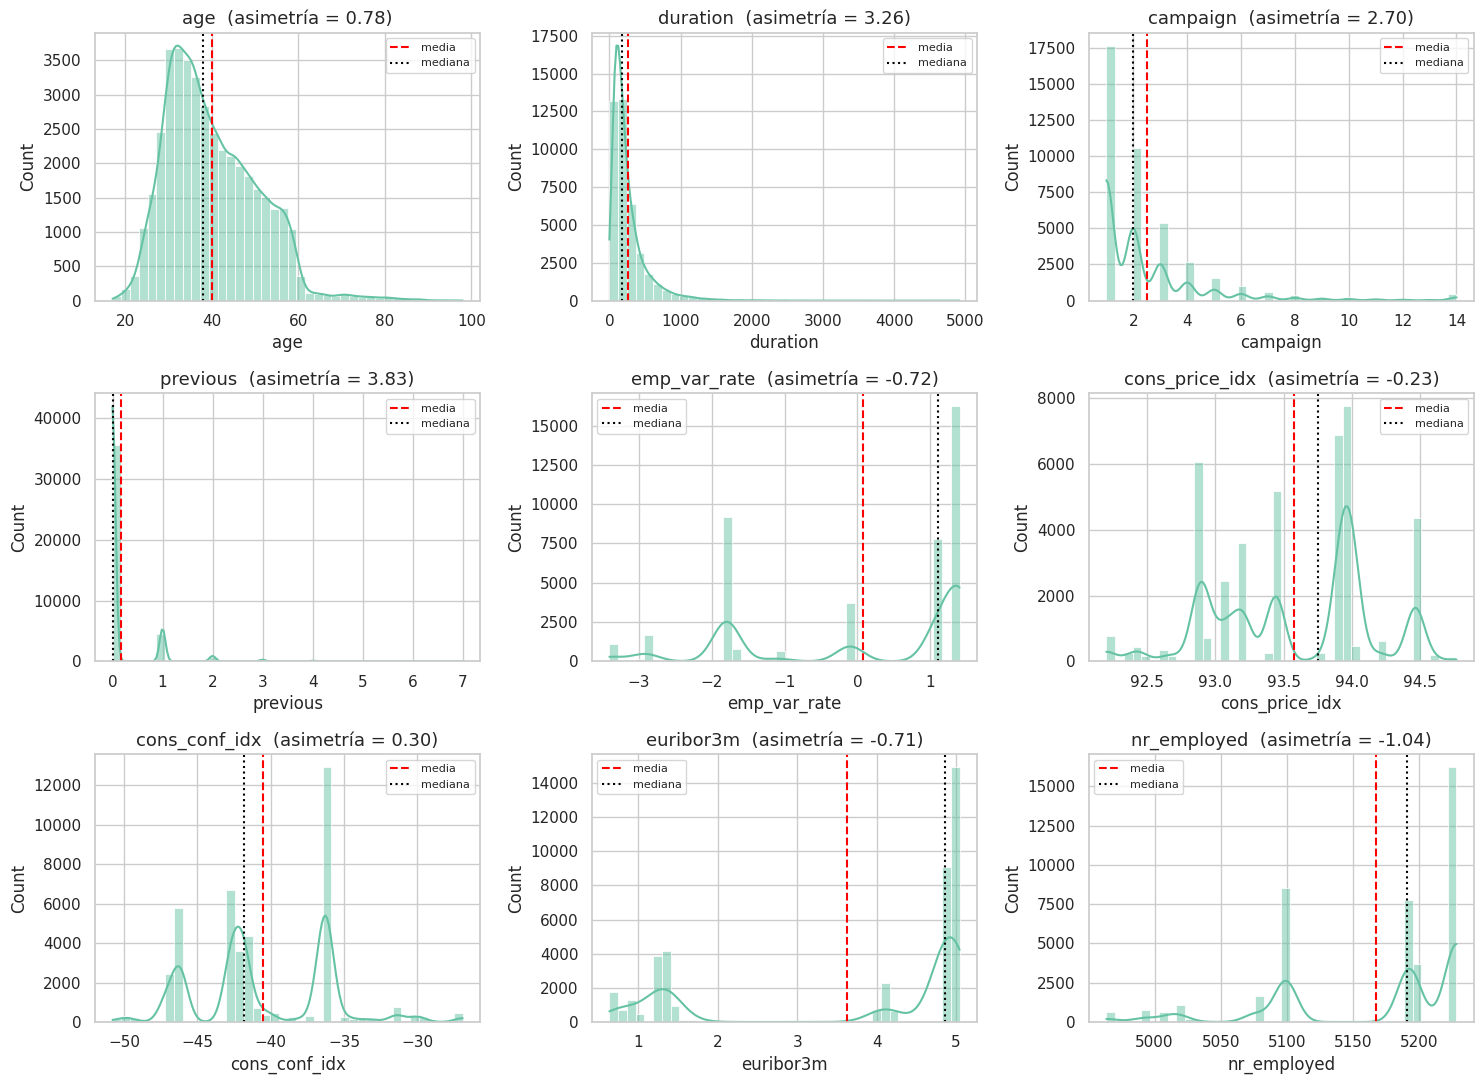

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for col, ax in zip(num, axes.flat):
    sns.histplot(df[col], kde=True, ax=ax, bins=40, color="#66c2a5")
    ax.axvline(df[col].mean(), color="red", ls="--", label="media")
    ax.axvline(df[col].median(), color="black", ls=":", label="mediana")
    ax.set_title(f"{col}  (asimetría = {df[col].skew():.2f})")
    ax.legend(fontsize=8)
plt.tight_layout()
guardar_figura("03_histogramas")
plt.show()

### Prueba de normalidad (D'Agostino-Pearson)
H0: la variable sigue una distribución normal. Si p < 0.05 se rechaza la normalidad.

In [5]:
filas = []
for col in num:
    estad, p = stats.normaltest(df[col])
    filas.append([col, round(estad, 1), p, "No normal" if p < 0.05 else "Normal"])
pd.DataFrame(filas, columns=["variable", "estadístico", "p_valor", "conclusión"]).set_index("variable")

,estadístico,p_valor,conclusión
variable,,,
age,3902.6,0.000000e+00,No normal
duration,30123.1,0.000000e+00,No normal
campaign,23341.3,0.000000e+00,No normal
previous,33207.0,0.000000e+00,No normal
emp_var_rate,16401.9,0.000000e+00,No normal
cons_price_idx,4389.9,0.000000e+00,No normal
cons_conf_idx,936.2,5.147000e-204,No normal
euribor3m,366903.1,0.000000e+00,No normal
nr_employed,5197.4,0.000000e+00,No normal


Ninguna variable numérica es normal. Las más problemáticas son `duration`, `campaign` y `previous` (fuerte **sesgo positivo** / cola a la derecha). Las macroeconómicas (`euribor3m`, `nr_employed`, `emp_var_rate`) son **multimodales**: toman pocos valores porque cambian por trimestre o mes.

## 4. Transformaciones para variables sesgadas

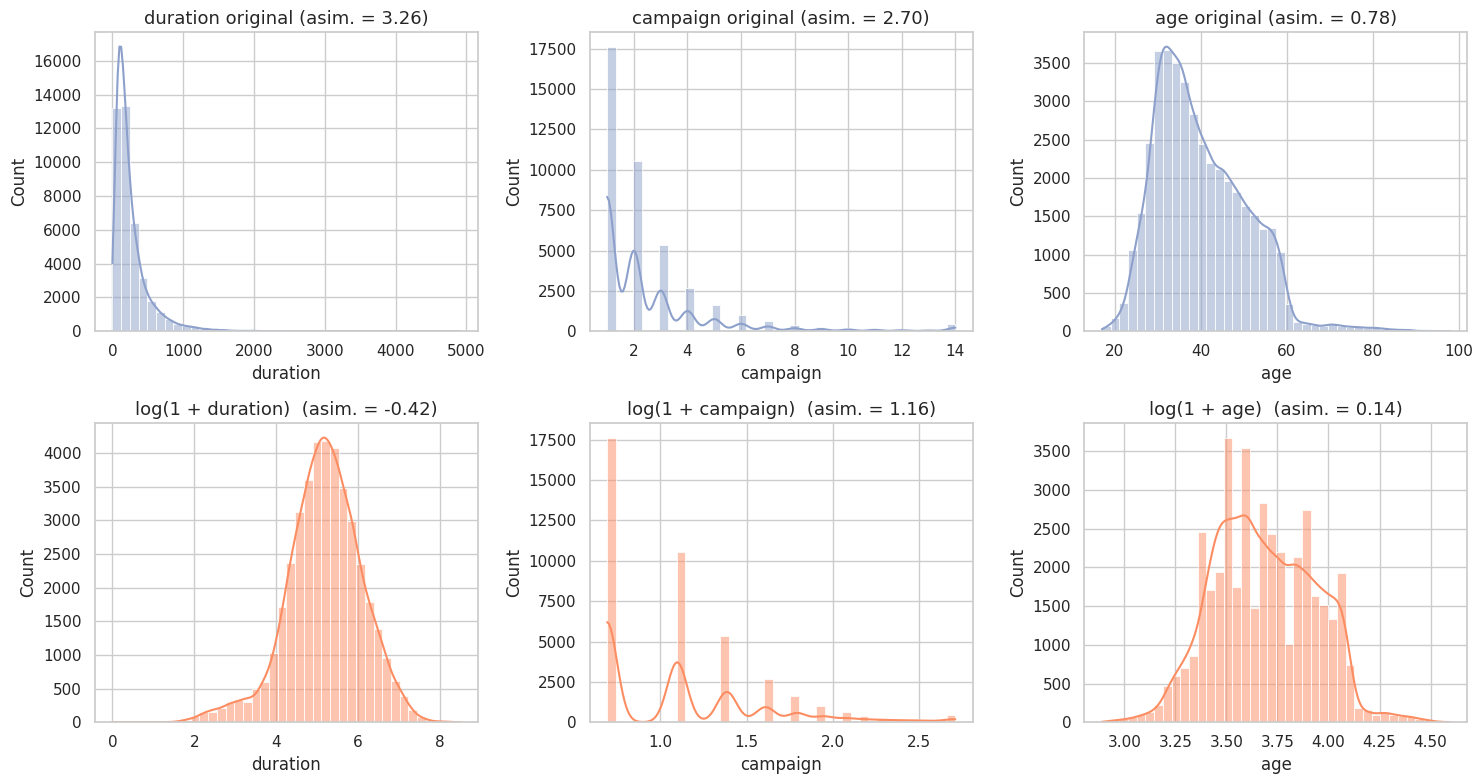

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(["duration", "campaign", "age"]):
    sns.histplot(df[col], kde=True, ax=axes[0, i], bins=40, color="#8da0cb")
    axes[0, i].set_title(f"{col} original (asim. = {df[col].skew():.2f})")
    transformada = np.log1p(df[col])
    sns.histplot(transformada, kde=True, ax=axes[1, i], bins=40, color="#fc8d62")
    axes[1, i].set_title(f"log(1 + {col})  (asim. = {transformada.skew():.2f})")
plt.tight_layout()
guardar_figura("03_transformacion_log")
plt.show()

La transformación logarítmica reduce mucho el sesgo de `duration` y `campaign`, por lo que se recomienda aplicarla (o usar un escalado robusto) antes de un modelo sensible a la escala. Después se aplicará **estandarización** (media 0, desviación 1) en el notebook de preprocesamiento.

## 5. Análisis univariado de variables categóricas

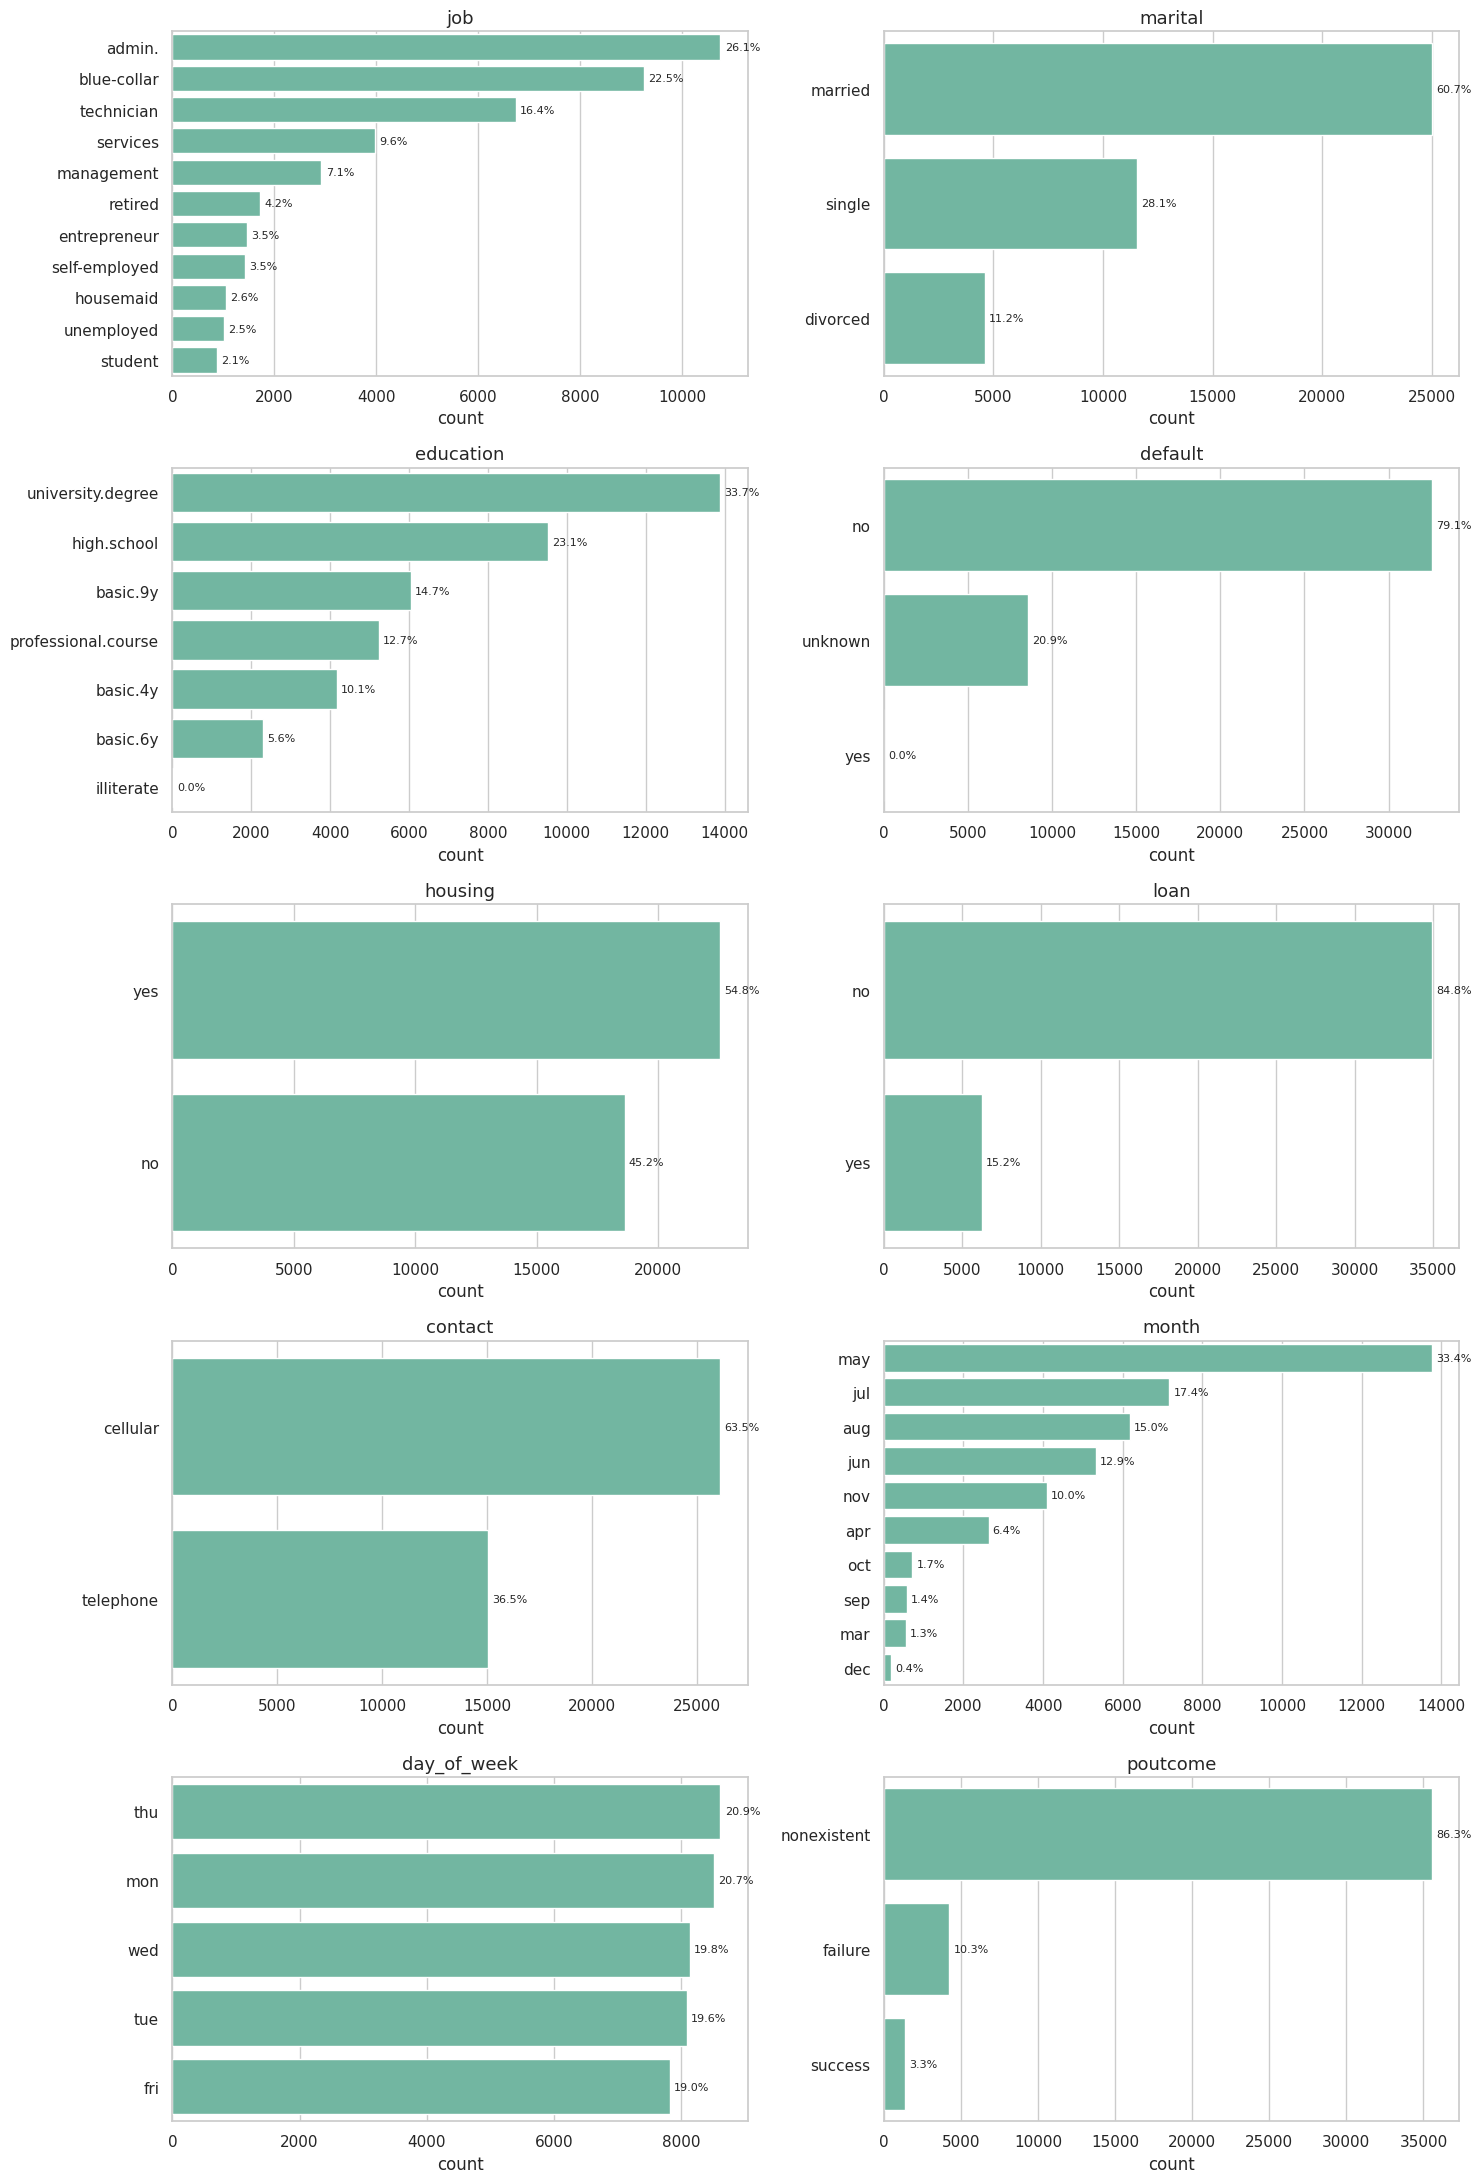

In [7]:
cats = VARIABLES_CATEGORICAS
fig, axes = plt.subplots(5, 2, figsize=(15, 22))
for col, ax in zip(cats, axes.flat):
    orden = df[col].value_counts().index
    sns.countplot(y=df[col], order=orden, ax=ax, color="#66c2a5")
    total = len(df)
    for p in ax.patches:
        ax.annotate(f"{p.get_width()/total*100:.1f}%", (p.get_width(), p.get_y() + p.get_height()/2),
                    va="center", fontsize=8, xytext=(3, 0), textcoords="offset points")
    ax.set_title(col); ax.set_ylabel("")
plt.tight_layout()
guardar_figura("03_barras_categoricas")
plt.show()

In [8]:
resumen_cat = pd.DataFrame({
    "n_categorias": df[cats].nunique(),
    "moda": df[cats].mode().iloc[0],
    "%_moda": [round(df[c].value_counts(normalize=True).iloc[0] * 100, 1) for c in cats],
})
resumen_cat

,n_categorias,moda,%_moda
job,11,admin.,26.1
marital,3,married,60.7
education,7,university.degree,33.7
default,3,no,79.1
housing,2,yes,54.8
loan,2,no,84.8
contact,2,cellular,63.5
month,10,may,33.4
day_of_week,5,thu,20.9
poutcome,3,nonexistent,86.3


## 6. Conclusiones del análisis univariado
1. **Objetivo desbalanceado:** ≈11,3 % de éxito vs ≈88,7 % de fracaso.
2. **Clientes típicos:** edad mediana de 38 años, casados (~61 %), con trabajo administrativo, *blue-collar* o técnico.
3. **Contacto:** la mayoría fue por celular (~63 %) y la campaña se concentró en **mayo** (~33 % de las llamadas).
4. **`poutcome`:** ~86 % de los clientes nunca participó en una campaña anterior (`nonexistent`).
5. **Distribuciones sesgadas:** `duration`, `campaign` y `previous` requieren transformación logarítmica o escalado robusto.
6. **Variables macro** con pocos valores distintos: se comportan casi como variables categóricas (reflejan el momento económico).